# Demo 1: Basic project creation, pose usage plots, and classification

## Initializing the project

First, we will import dependencies.

In [269]:
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import importlib
import pandas as pd
import numpy as np

#This block only important for running as script
# script_dir = os.path.dirname(os.path.abspath(__file__))
# mariposa_dir = os.path.dirname(script_dir)
# utils_dir = os.path.join(mariposa_dir, 'utils')
# sys.path.append(utils_dir)
# sys.path.append(mariposa_dir)

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)

<module 'utils.plot' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/plot.py'>

Then we will set the paths for our config file and where and whether to save plots, and then load the config!

In [270]:
config_paths=["/Users/snewbank/Behavior/MARIPOSA_test/240827_BSOID-test/config_PS.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240901_KPMS-full/config_PS.yaml"]

save_paths=["/Users/snewbank/Behavior/MARIPOSA_test/240827_BSOID-test/demo/",
            "/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/demo/",
            "/Users/snewbank/Behavior/MARIPOSA_test/240901_KPMS-full/demo/"]

dset=1
config_path=config_paths[dset]
save_path=save_paths[dset]
save=False

#Load config
config = metadata.load_project(config_path)

## Computing and visualizing module usage

Now we will plot pose usage without subgroups.

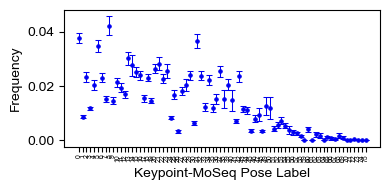

In [3]:
#plot without subgroups
labels_df, n_modules = analysis.label_counter_nosubgroups(config,0,10)
fig = plot.plot_module_usage(config, labels_df, 0, 10, style="points")
if save == True:
    plt.savefig(save_path+"labels_no_subgroups.png",dpi=500)

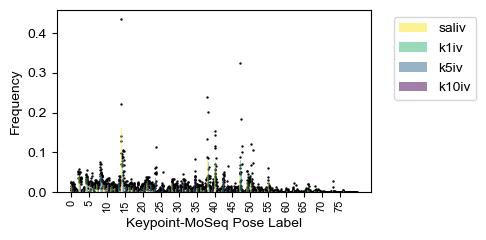

In [4]:
selected_subgroups=["saliv","k1iv","k5iv","k10iv"]
labels_df, n_modules = analysis.label_counter_subgroups(config, 0, 1200,selected_subgroups=selected_subgroups)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200, figW=5, figH=2.5, legend_pos="outside",
                                       style="bar_scatter")
if save == True:
    plt.savefig(save_path + "labels_subgroups.png", dpi=500)

Then we will do a network-style visualization of how pose usage and transition frequency differs between two groups

P-value for cluster 2 difference is 0.0086; t score is 3.1384
P-value for cluster 3 difference is 0.0002; t score is -5.4295
P-value for cluster 4 difference is 0.0089; t score is 3.1163
P-value for cluster 6 difference is 0.001; t score is -4.2947
P-value for cluster 8 difference is 0.0088; t score is 3.1212
P-value for cluster 13 difference is 0.0035; t score is -3.6237
P-value for cluster 16 difference is 0.0166; t score is -2.7828
P-value for cluster 18 difference is 0.0; t score is -6.6712
P-value for cluster 19 difference is 0.0; t score is -8.9953
P-value for cluster 20 difference is 0.0002; t score is -5.2216
P-value for cluster 22 difference is 0.0243; t score is -2.5747
P-value for cluster 23 difference is 0.0013; t score is -4.1731
P-value for cluster 24 difference is 0.0002; t score is -5.1745
P-value for cluster 25 difference is 0.0097; t score is -3.0729
P-value for cluster 26 difference is 0.0205; t score is -2.6665
P-value for cluster 30 difference is 0.0008; t score is

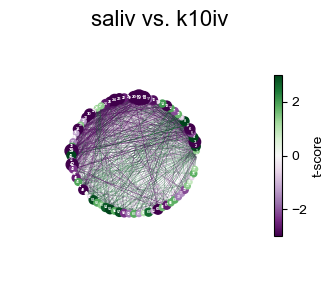

In [5]:
comparison_groups=["saliv","k10iv"]
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200)
fig = plot.network_pairwise_comparison(config, labels_df, 0, 1200, comparison_groups,cmap="PRGn")
if save == True:
    plt.savefig(save_path+"network_comparison.png",dpi=500)

And now a "sand plot" showing mean pose usage density over time in a group.

/Users/snewbank/PycharmProjects/MARIPoSA/utils/plot.py:560: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
/Users/snewbank/PycharmProjects/MARIPoSA/utils/plot.py:560: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


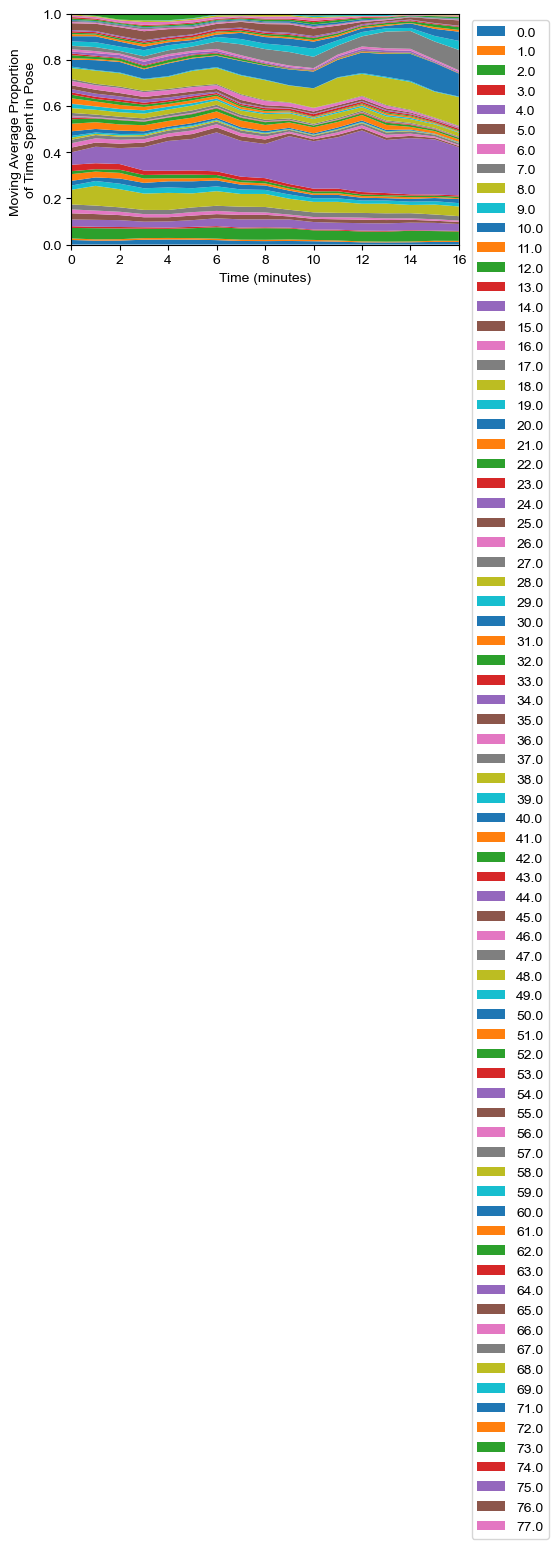

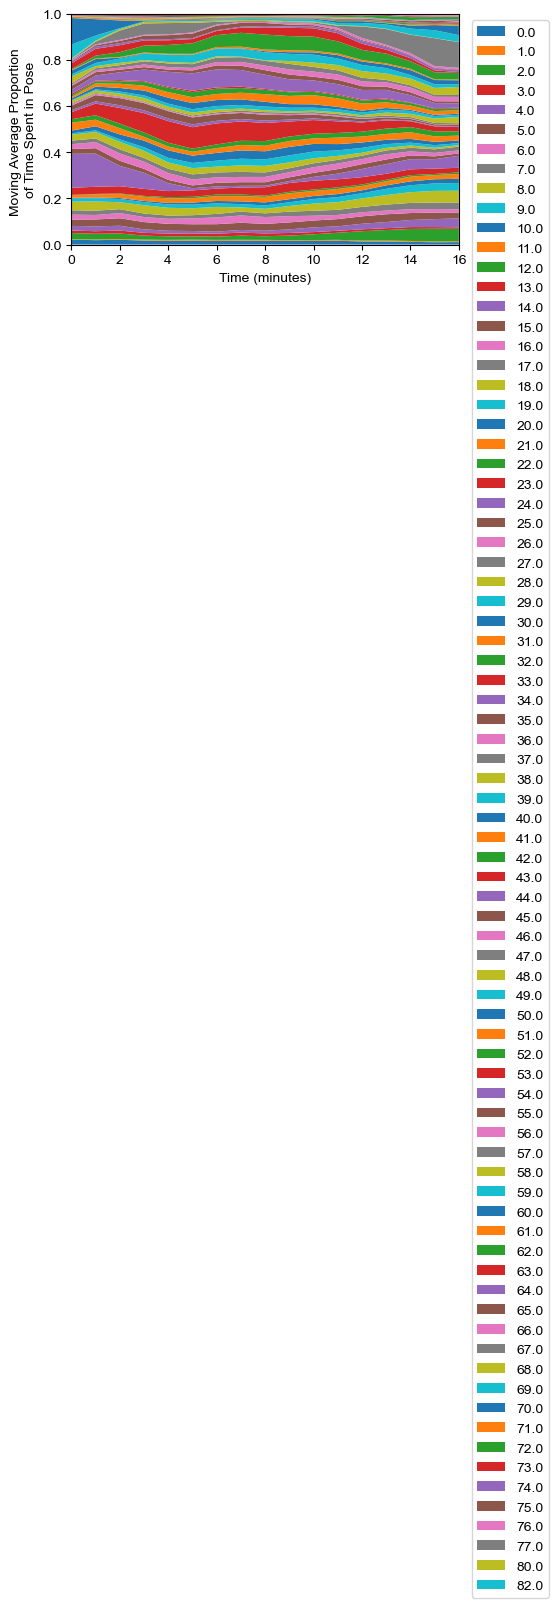

In [6]:
group="saliv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,figW=5,figH=3)
if save==True:
    plt.savefig(save_path+group+"_sandplot.png",dpi=500)

group="k10iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*20,selected_subgroups=[group])
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 20,figW=5,figH=3)
if save==True:
    plt.savefig(save_path+group+"_sandplot.png",dpi=500)

And now, let's look at some of these same analyses "remapped" into manual scoring space with our BORIS-to-pose-file mappings.

done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
Keypoint-MoSeq modules map onto scored behaviors with 'loss' of 0.40997770345596435
done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
Keypoint-MoSeq modules map onto scored behaviors with 'loss' of 0.40997770345596435
Applying 78 remapping rules from config.
1 of 78: Remapping [0.0] to ataxic 1-3
2 of 78: Remapping [1.0] to ataxic 1-3
3 of 78: Remapping [2.0] to ataxic 4-5
4 of 78: Remapping [

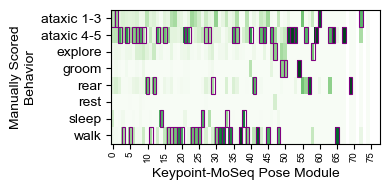

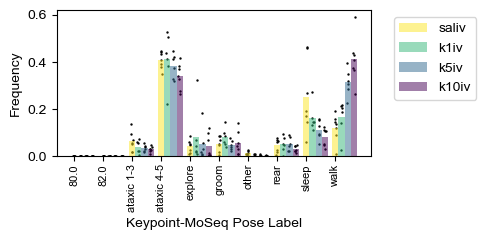

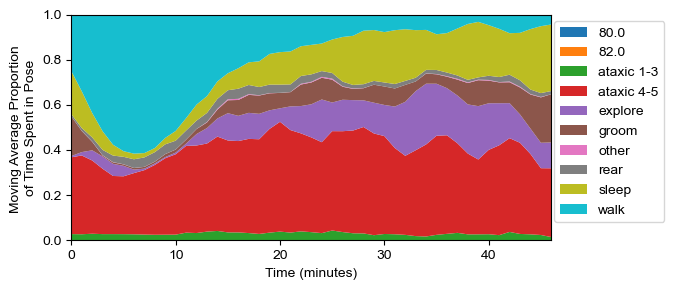

In [7]:
#BORIS to pose
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
plot.BORIS_to_pose_matrix_plot(config, BORIS_to_pose_mat_normalized,figH=2,figW=4)
if save == True:
    plt.savefig(save_path+"boris_to_pose.png",dpi=500)

#remapping
selected_subgroups=["saliv","k1iv","k5iv","k10iv"]
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.plot_module_usage_subgroups(config, labels_df, 0, 1200,figW=5,figH=2.5,legend_pos="outside")
if save==True:
    plt.savefig(save_path+"remapped_labels_subgroups.png",dpi=500)

#plot over time - remapped
group="k10iv"
labels_df, n_modules = analysis.label_counter_subgroups(config,0,60*50,selected_subgroups=[group])
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
labels_df = analysis.make_remappings_from_BORIS(config, labels_df, BORIS_to_pose_mat)
fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 60, 50)
if save==True:
    plt.savefig(save_path+"remapped_sandplot.png",dpi=500)

## Classification with Linear Discriminant Analysis

Now we will do some classification! Let's just start with a simple linear discriminant analysis based on module usage across an entire session - no time blocks or feature subselection. To achieve this, we will use our analysis.label_counter_subgroups function and a new function, analysis.lda_labels_timebins, which outputs a result of class LdaResult containing the fitted LDA model, the input features and class labels, and (optionally) leave-one-out cross-validation accuracy and confusion matrix.

Features selected by f-stat were: module1_t0-300, module2_t0-300, module8_t0-300, module9_t0-300, module11_t0-300, module14_t0-300, module1_t300-600, module2_t300-600, module8_t300-600, module2_t600-900, module8_t600-900.
0.8076923076923077


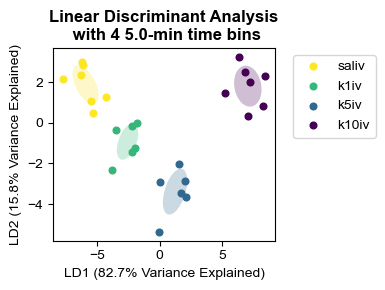

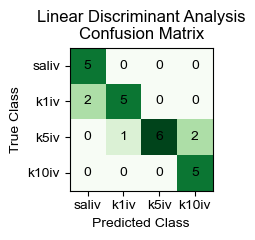

In [273]:
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
lda_result = analysis.lda_labels_timebins(config,labels_df,300,feature_selection=("f",10),loocv=True,selected_subgroups=selected_subgroups)
#lda_result = analysis.lda_labels_timebins(config,labels_df,1200,loocv=True,selected_subgroups=selected_subgroups)
fig = plot.plot_lda(config, lda_result, cmap="viridis_r",draw_ellipse=True)
if save==True:
    plt.savefig(save_path+"lda_embeddings_f10_bs300.png",dpi=500)
plot.plot_conf_mat(lda_result,alt_title="Linear Discriminant Analysis\nConfusion Matrix")
print(lda_result.loocv_accuracy)
if save == True:
    plt.savefig(save_path+"lda_confmat_f10_bs300.png",dpi=500)

done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.3304357516995431


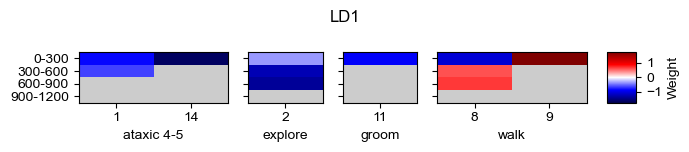

done with ['2023-07-18_18-19-50_bm04_k10iv_2023-07-18_18-19-50_bm04_k10iv.csv', '2023-07-18_18-19-50_bm04_k10iv']
done with ['2023-06-20_19-10-38_bf04_k1iv_2023-06-20_19-10-38_bf04_k1iv.csv', '2023-06-20_19-10-38_bf04_k1iv']
VAME modules map onto scored behaviors with 'loss' of 0.3304357516995431


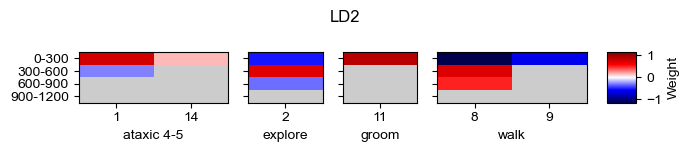

In [274]:
figs = plot.plot_lda_weights(config, lda_result,n_modules,hide_nofeat_mods=True,remap=True,figW=7,figH=1.5)
# if save==True:
#     figs[0].savefig(save_path+"ld1.png",dpi=500)
#     figs[1].savefig(save_path+"ld2.png",dpi=500)

In [266]:
figs[0].savefig(save_path+"ld1.png",dpi=500)

And then we'll scan different bin widths (seconds) to see what time discretization gives the best classification performance. 

In [9]:
binsizes=[1*60,2.5*60,5*60,10*60,20*60]
n_feats=[5,10,25,50,100,50000]
accuracies=pd.DataFrame(columns=binsizes,index=n_feats)
labels_df, n_modules = analysis.label_counter_subgroups(config,0,1200,selected_subgroups=selected_subgroups)
for binsize in binsizes:
    for n in n_feats:
        lda_result = analysis.lda_labels_timebins(config,labels_df,binsize,feature_selection=("f",n), loocv=True,selected_subgroups=selected_subgroups)
        accuracies.at[n,binsize]=lda_result.loocv_accuracy
        print(f"Accuracy at {binsize} binsize, {n} feats was {lda_result.loocv_accuracy}")


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/s

Features selected by f-stat were: module42_t180-240, module19_t240-300, module23_t660-720, module34_t660-720, module19_t780-840, module42_t780-840.
Accuracy at 60 binsize, 5 feats was 0.6923076923076923


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/s

Features selected by f-stat were: module42_t180-240, module19_t240-300, module19_t360-420, module19_t420-480, module23_t660-720, module24_t660-720, module34_t660-720, module15_t780-840, module19_t780-840, module24_t780-840, module42_t780-840.
Accuracy at 60 binsize, 10 feats was 0.46153846153846156


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/s

...

/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/s

Features selected by f-stat were: module2, module3, module4, module5, module6, module8, module10, module11, module12, module13, module14, module16, module17, module18, module19, module20, module22, module23, module24, module25, module26, module30, module31, module34, module37, module38, module39, module40, module42, module43, module45, module48, module51, module54, module55, module56, module57, module58, module59, module60, module61, module63, module65, module67, module68, module69, module70, module71, module72, module73, module76.
Accuracy at 1200 binsize, 50 feats was 0.8076923076923077


/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/s

Features selected by f-stat were: module0, module1, module2, module3, module4, module5, module6, module7, module8, module9, module10, module11, module12, module13, module14, module15, module16, module17, module18, module19, module20, module21, module22, module23, module24, module25, module26, module27, module28, module29, module30, module31, module32, module33, module34, module35, module36, module37, module38, module39, module40, module41, module42, module43, module44, module45, module46, module47, module48, module49, module50, module51, module52, module53, module54, module55, module56, module57, module58, module59, module60, module61, module62, module63, module64, module65, module66, module67, module68, module69, module70, module71, module72, module73, module74, module75, module76, module77.
Accuracy at 1200 binsize, 100 feats was 0.8076923076923077
Features selected by f-stat were: module0, module1, module2, module3, module4, module5, module6, module7, module8, module9, module10, mod

/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/scipy/stats/_stats_py.py:3895: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))
/opt/anaconda3/envs/mariposa/lib/python3.8/s

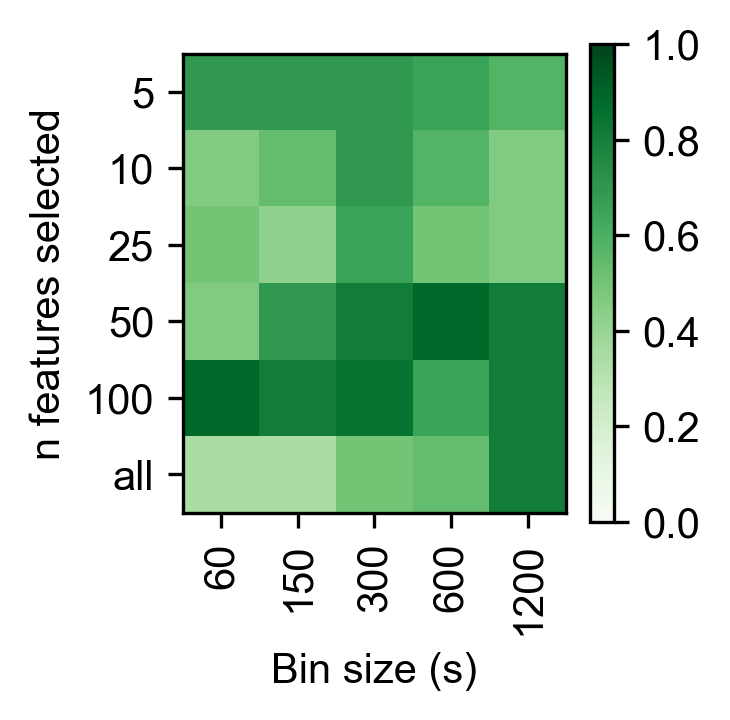

In [10]:
n_feats=list(accuracies.index)
binsizes=list(np.array(accuracies.columns,dtype=int))
plt.figure(figsize=(2.5,2.5),dpi=300)
plt.imshow(np.array(accuracies,dtype=np.float32),cmap="Greens",vmin=0,vmax=1)
plt.xticks(range(len(binsizes)),binsizes,rotation=90)
plt.xlabel("Bin size (s)")
n_feats[-1]="all"
plt.yticks(range(len(n_feats)),n_feats)
plt.ylabel("n features selected")
plt.colorbar()
plt.tight_layout()

if save == True:
    plt.savefig(save_path+"scan_lda_params.png",dpi=500)
    accuracies = pd.DataFrame(accuracies,dtype=np.float32)
    accuracies.to_csv(save_path+"scan_lda_params.csv")

0.6256410276666666
0.88461536


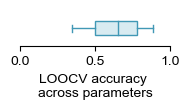

In [11]:
c1="#4198B5"
c2="#D8EBF1"

accuracies = pd.read_csv(save_path+"scan_lda_params.csv",index_col=0)

plt.figure(figsize=(2, 1.2))
box = plt.boxplot(np.array(accuracies.stack()), 
                   patch_artist=True,
                   boxprops=dict(facecolor=c2, color=c1),
                   whiskerprops=dict(color=c1),
                   capprops=dict(color=c1),
                   medianprops=dict(color=c1),
                   flierprops=dict(markerfacecolor=c1, marker='o'), vert=False)

plt.xlim([0, 1])
pad=0.2
plt.ylim([1-pad,1+pad])
plt.xlabel('LOOCV accuracy \nacross parameters')
plt.yticks([])

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()

print(np.mean(accuracies))
print(np.max(accuracies))
if save==True:
    plt.savefig(save_path+"loocv_acrossparams_boxplot.png",dpi=500)